In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
import os
import json
import pandas as pd
from collections import Counter

# Paths
base_path = '.'  # Replace with your actual path
rgb_path = os.path.join(base_path, 'rgb')
train_json = os.path.join(base_path, 'Diving48_V2_train.json')
test_json = os.path.join(base_path, 'Diving48_V2_test.json')
vocab_json = os.path.join(base_path, 'Diving48_vocab.json')

# Load JSONs
with open(train_json, 'r') as f:
    train_data = json.load(f)

with open(test_json, 'r') as f:
    test_data = json.load(f)

with open(vocab_json, 'r') as f:
    vocab_data = json.load(f)

# Convert to DataFrame for easy handling
df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

# Show head
print("Train Data Head:")
print(df_train.head())

print("\nTest Data Head:")
print(df_test.head())

# Count unique classes
train_classes = df_train['label'].unique()
test_classes = df_test['label'].unique()
print(f"\nUnique Classes in Train: {len(train_classes)}")
print(f"Unique Classes in Test: {len(test_classes)}")

# Class distribution
print("\nTrain Class Distribution:")
print(df_train['label'].value_counts())

print("\nTest Class Distribution:")
print(df_test['label'].value_counts())

# Check total MP4 files in RGB folder
mp4_files = [f for f in os.listdir(rgb_path) if f.endswith('.mp4')]
print(f"\nTotal video files in rgb/: {len(mp4_files)}")

Train Data Head:
            vid_name  label  start_frame  end_frame
0  -mmq0PT-u8k_00155      0            0         48
1  -mmq0PT-u8k_00156      0            0         70
2  -mmq0PT-u8k_00157      0            0         90
3  3qq031609lA_00002      0            0        123
4  3qq031609lA_00004      0            0        102

Test Data Head:
            vid_name  label  start_frame  end_frame
0  8qRmKunCjtY_00016      0            0         78
1  CVAfPfVFulQ_00038      0            0        100
2  CVAfPfVFulQ_00040      0            0         79
3  CVAfPfVFulQ_00048      0            0         76
4  CVAfPfVFulQ_00049      0            0         83

Unique Classes in Train: 47
Unique Classes in Test: 47

Train Class Distribution:
label
26    1053
35     992
7      901
46     816
21     689
31     683
19     604
15     591
34     571
33     568
45     559
44     518
24     484
5      467
8      424
12     421
43     406
22     355
17     349
36     346
28     326
3      259
27     250


In [3]:
df_vocab = pd.read_csv("df_vocab.csv")
df_vocab

,Unnamed: 0,0,1,2,3,count
0,0,Back,15som,05Twis,FREE,220
1,1,Back,15som,15Twis,FREE,122
2,2,Back,15som,25Twis,FREE,59
3,3,Back,15som,NoTwis,PIKE,251
4,4,Back,15som,NoTwis,TUCK,40
5,5,Back,25som,15Twis,PIKE,509
6,6,Back,25som,25Twis,PIKE,184
7,7,Back,25som,NoTwis,PIKE,960
8,8,Back,25som,NoTwis,TUCK,410
9,9,Back,2som,15Twis,FREE,206


In [6]:
df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all

,vid_name,label,start_frame,end_frame
0,-mmq0PT-u8k_00155,0,0,48
1,-mmq0PT-u8k_00156,0,0,70
2,-mmq0PT-u8k_00157,0,0,90
3,3qq031609lA_00002,0,0,123
4,3qq031609lA_00004,0,0,102
...,...,...,...,...
16992,mGRum47TLX0_00040,47,0,56
16993,mGRum47TLX0_00044,47,0,112
16994,ovWCmIMMkRI_00050,47,0,108
16995,ovWCmIMMkRI_00051,47,0,125


In [7]:
train_list = os.listdir("videosTensors1000/")
train_list

['db7DmpqzGmc_00088_tracking.pt',
 '5hXbclLNSNA_00010_tracking.pt',
 'roFeEJPgJD8_00022_tracking.pt',
 'OFxuiqI5G44_00221_tracking.pt',
 'Le6xdQ2OO8w_00123_tracking.pt',
 'eN8umEok9U8_00196_tracking.pt',
 '5i1begTTucc_00053_tracking.pt',
 '_tigfCJFLZg_00321_tracking.pt',
 'l6ZoMjD1UtA_00011_tracking.pt',
 'Y4ARBzok9aU_00031_tracking.pt',
 'LkluZoNfKu8_00125_tracking.pt',
 '_8Vy3dlHg2w_00046_tracking.pt',
 'yHo2oERGo7A_00038_tracking.pt',
 'czXA41QTops_00063_tracking.pt',
 'zbAC7t15q3k_00061_tracking.pt',
 '9BC6ssCjyfg_00084_tracking.pt',
 'eN8umEok9U8_00009_tracking.pt',
 'OVzt2rsfMc0_00257_tracking.pt',
 'MbzIpx8kAD0_00057_tracking.pt',
 'DB4lpBDPnTY_00047_tracking.pt',
 'TeboS8s_00w_00114_tracking.pt',
 'zYHstCxnAPA_00713_tracking.pt',
 'OVzt2rsfMc0_00181_tracking.pt',
 'JzOshOJgofw_00020_tracking.pt',
 '6wVdnLa3Tes_00199_tracking.pt',
 '_tigfCJFLZg_00438_tracking.pt',
 'OFxuiqI5G44_00068_tracking.pt',
 '3PLiUG_DuC8_00175_tracking.pt',
 'ddV_Cpszpls_00080_tracking.pt',
 'Q--70-ELqLw_

In [8]:
len(train_list)

8482

In [18]:
df_exists_train = pd.read_csv("df_exsists.csv")
df_exists_train["label"].value_counts()

label
7     494
35    486
26    468
46    340
45    337
33    293
15    283
34    280
21    279
31    264
43    217
22    212
19    212
12    210
24    204
44    202
8     200
5     192
36    183
28    174
0     146
3     115
29    102
6     101
27    100
17     90
11     80
42     76
1      74
32     71
47     55
41     54
16     52
9      49
4      44
25     42
18     33
14     33
23     33
20     32
40     31
37     30
10     26
38     22
39     20
2      16
13     15
Name: count, dtype: int64

In [21]:
df_exists_train["label"].value_counts().index

Index([ 7, 35, 26, 46, 45, 33, 15, 34, 21, 31, 43, 22, 19, 12, 24, 44,  8,  5,
       36, 28,  0,  3, 29,  6, 27, 17, 11, 42,  1, 32, 47, 41, 16,  9,  4, 25,
       18, 14, 23, 20, 40, 37, 10, 38, 39,  2, 13],
      dtype='int64', name='label')

In [44]:
df_exists_train

,Unnamed: 0,vid_name,label,start_frame,end_frame
0,0,3qq031609lA_00002,0,0,123
1,1,3qq031609lA_00004,0,0,102
2,2,5V-dKBtmKLI_00018,0,0,55
3,3,5V-dKBtmKLI_00085,0,0,80
4,4,5V-dKBtmKLI_00086,0,0,89
...,...,...,...,...,...
7067,7067,mGRum47TLX0_00040,47,0,56
7068,7068,mGRum47TLX0_00044,47,0,112
7069,7069,ovWCmIMMkRI_00050,47,0,108
7070,7070,ovWCmIMMkRI_00051,47,0,125


In [24]:
TestProcessed = os.listdir("Test/")
TestProcessed

['uDESPUxbjnI_00136_tracking.pt',
 'JzOshOJgofw_00269_tracking.pt',
 'k1F4LHeYhBs_00156_tracking.pt',
 'nOlRwoxsDJ0_00545_tracking.pt',
 'nOlRwoxsDJ0_00015_tracking.pt',
 'VNvb5oLOpLg_01069_tracking.pt',
 'zYHstCxnAPA_00195_tracking.pt',
 'V5parOfpuEQ_00084_tracking.pt',
 '_tigfCJFLZg_00168_tracking.pt',
 'zYHstCxnAPA_00243_tracking.pt',
 '3PLiUG_DuC8_00175_tracking.pt',
 'sk8TafuB3lU_00337_tracking.pt',
 'nOlRwoxsDJ0_00693_tracking.pt',
 'sk8TafuB3lU_00808_tracking.pt',
 'S9aCrmtAV8o_00017_tracking.pt',
 'VNvb5oLOpLg_00432_tracking.pt',
 'Y7QZcr24ye0_00433_tracking.pt',
 'sk8TafuB3lU_00255_tracking.pt',
 'zYHstCxnAPA_00321_tracking.pt',
 'nOlRwoxsDJ0_00801_tracking.pt',
 'xbQCwTHcGN8_00257_tracking.pt',
 'Q--70-ELqLw_00174_tracking.pt',
 'sk8TafuB3lU_01088_tracking.pt',
 'VNvb5oLOpLg_00550_tracking.pt',
 'OFxuiqI5G44_00095_tracking.pt',
 'S9aCrmtAV8o_00175_tracking.pt',
 'ZAmJsIcfFOA_00171_tracking.pt',
 'k1F4LHeYhBs_00034_tracking.pt',
 'OFxuiqI5G44_00343_tracking.pt',
 '5V-dKBtmKLI_

In [25]:
len(TestProcessed)

4242

In [26]:
testNotProcessed = pd.read_csv("NotTestProceesed22July.csv")

In [27]:
testNotProcessed

,Names
0,_8Vy3dlHg2w_00044
1,_lmT4WlK7G0_00099
2,_lmT4WlK7G0_00117
3,_tigfCJFLZg_00045
4,_tigfCJFLZg_00234
...,...
311,zYHstCxnAPA_00262
312,zYHstCxnAPA_00299
313,zYHstCxnAPA_00302
314,zYHstCxnAPA_00306


In [34]:


def get_valid_names_from_list(name_list, df):
    cleaned_name_map = {name: name.replace('_tracking.pt', '') for name in name_list}
    if 'Names' not in df.columns:
        raise ValueError("CSV must contain a 'Names' column")

    csv_names = set(df['Names'].astype(str).tolist())

    valid_names = [orig for orig, cleaned in cleaned_name_map.items() if cleaned not in csv_names]

    return valid_names

In [36]:
valid_names = get_valid_names_from_list(TestProcessed, testNotProcessed)

In [37]:
len(valid_names)

3934

In [42]:
valid_names = [name.replace('_tracking.pt', '') for name in valid_names]
valid_names

['uDESPUxbjnI_00136',
 'JzOshOJgofw_00269',
 'k1F4LHeYhBs_00156',
 'nOlRwoxsDJ0_00545',
 'nOlRwoxsDJ0_00015',
 'VNvb5oLOpLg_01069',
 'zYHstCxnAPA_00195',
 'V5parOfpuEQ_00084',
 '_tigfCJFLZg_00168',
 'zYHstCxnAPA_00243',
 '3PLiUG_DuC8_00175',
 'sk8TafuB3lU_00337',
 'nOlRwoxsDJ0_00693',
 'sk8TafuB3lU_00808',
 'S9aCrmtAV8o_00017',
 'VNvb5oLOpLg_00432',
 'Y7QZcr24ye0_00433',
 'sk8TafuB3lU_00255',
 'zYHstCxnAPA_00321',
 'nOlRwoxsDJ0_00801',
 'xbQCwTHcGN8_00257',
 'Q--70-ELqLw_00174',
 'sk8TafuB3lU_01088',
 'VNvb5oLOpLg_00550',
 'OFxuiqI5G44_00095',
 'S9aCrmtAV8o_00175',
 'k1F4LHeYhBs_00034',
 'OFxuiqI5G44_00343',
 '5V-dKBtmKLI_00001',
 'VNvb5oLOpLg_00686',
 '9BC6ssCjyfg_00079',
 'ZAmJsIcfFOA_00338',
 'VNvb5oLOpLg_00719',
 'zBXtMcI41z8_00076',
 'nOlRwoxsDJ0_00177',
 'VNvb5oLOpLg_00249',
 'nOlRwoxsDJ0_00427',
 'OFxuiqI5G44_00251',
 'k1F4LHeYhBs_00126',
 'nOlRwoxsDJ0_00535',
 'Y7QZcr24ye0_01018',
 'nOlRwoxsDJ0_00065',
 'sk8TafuB3lU_00617',
 'TeboS8s_00w_00164',
 'DB4lpBDPnTY_00037',
 'VNvb5oLO

In [54]:
finalCorrectProcessed = df_exists_train["vid_name"].tolist() + valid_names
print(len(finalCorrectProcessed))
df_all = df_all[df_all["vid_name"].isin(finalCorrectProcessed)]

11006


In [55]:
df_all["label"].value_counts()

label
26    691
7     662
35    610
46    603
15    495
21    463
45    450
34    434
31    432
19    394
44    386
33    378
24    347
8     330
5     330
12    320
43    291
36    290
22    271
28    237
17    232
0     214
3     190
27    180
29    153
6     146
1     120
11    120
42     91
41     85
32     82
9      71
16     64
47     62
38     57
18     54
25     53
14     50
4      50
37     47
23     44
20     43
40     38
10     37
39     35
2      32
13     18
Name: count, dtype: int64

In [56]:
df_all

,vid_name,label,start_frame,end_frame
3,3qq031609lA_00002,0,0,123
4,3qq031609lA_00004,0,0,102
5,5V-dKBtmKLI_00018,0,0,55
7,5V-dKBtmKLI_00085,0,0,80
8,5V-dKBtmKLI_00086,0,0,89
...,...,...,...,...
16992,mGRum47TLX0_00040,47,0,56
16993,mGRum47TLX0_00044,47,0,112
16994,ovWCmIMMkRI_00050,47,0,108
16995,ovWCmIMMkRI_00051,47,0,125


#### 00

In [59]:
import pandas as pd

def analyze_class_split(df, valid_names, total_classes=48, missing_class=30):
    df['set'] = df['vid_name'].apply(lambda x: 'test' if x in valid_names else 'train')

    total_counts = df['label'].value_counts().to_dict()
    train_counts = df[df['set'] == 'train']['label'].value_counts().to_dict()
    test_counts = df[df['set'] == 'test']['label'].value_counts().to_dict()

    data = []

    for cls in range(total_classes):
        if cls == missing_class:
            continue
        total = total_counts.get(cls, 0)
        train = train_counts.get(cls, 0)
        test = test_counts.get(cls, 0)

        data.append({
            'Class': cls,
            '% in Train': round(100 * train / total, 2) if total > 0 else 0.0,
            '% in Test': round(100 * test / total, 2) if total > 0 else 0.0,
            'Total Samples': total,
            'Train Samples': train,
            'Test Samples': test
        })

    return pd.DataFrame(data)

In [61]:
percentTrainTest = analyze_class_split(df_all, valid_names)

/var/folders/8g/y90dcmtn1t39t7rwgnkvjspm0000gn/T/ipykernel_39897/248808343.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['set'] = df['vid_name'].apply(lambda x: 'test' if x in valid_names else 'train')


In [64]:
percentTrainTest

,Class,% in Train,% in Test,Total Samples,Train Samples,Test Samples
0,0,67.76,32.24,214,145,69
1,1,61.67,38.33,120,74,46
2,2,50.00,50.00,32,16,16
3,3,60.53,39.47,190,115,75
4,4,88.00,12.00,50,44,6
5,5,58.18,41.82,330,192,138
6,6,67.81,32.19,146,99,47
7,7,73.72,26.28,662,488,174
8,8,60.00,40.00,330,198,132
9,9,66.20,33.80,71,47,24


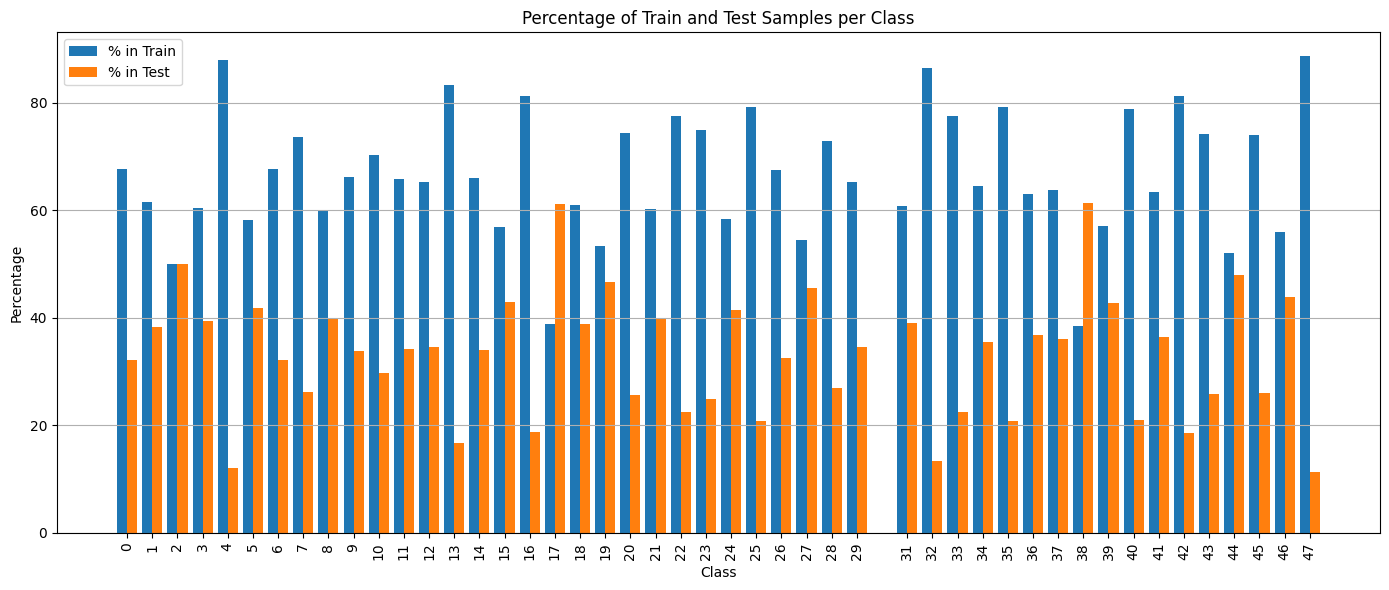

In [67]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
bar_width = 0.4
x = percentTrainTest['Class']

plt.bar(x - bar_width/2, percentTrainTest['% in Train'], width=bar_width, label='% in Train')
plt.bar(x + bar_width/2, percentTrainTest['% in Test'], width=bar_width, label='% in Test')

plt.xlabel("Class")
plt.ylabel("Percentage")
plt.title("Percentage of Train and Test Samples per Class")
plt.legend()
plt.xticks(ticks=x, labels=x, rotation=90)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


Per-Class Train/Test Distribution:
       Train Count  Test Count  Total  Train %  Test %
label                                                 
0              146          60    206    70.87   29.13
1               74          40    114    64.91   35.09
2               16          15     31    51.61   48.39
3              115          57    172    66.86   33.14
4               44           5     49    89.80   10.20
5              192         129    321    59.81   40.19
6              101          45    146    69.18   30.82
7              494         162    656    75.30   24.70
8              200         113    313    63.90   36.10
9               49          20     69    71.01   28.99
10              26           9     35    74.29   25.71
11              80          39    119    67.23   32.77
12             210         106    316    66.46   33.54
13              15           3     18    83.33   16.67
14              33          15     48    68.75   31.25
15             283         18

<Figure size 1600x600 with 0 Axes>

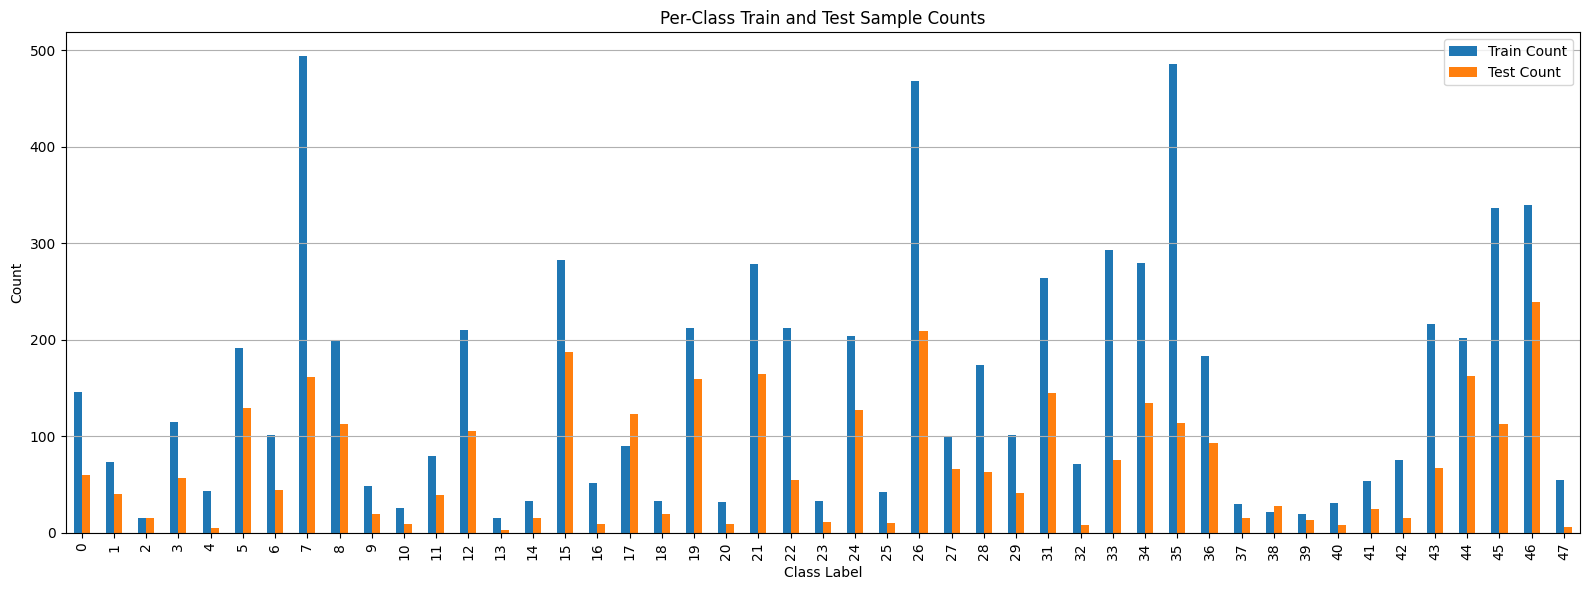

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# === Update these paths correctly ===
TRAIN_DF_PATH = "/Users/mrinalraj/Downloads/WebDownload/Driving48/df_exsists.csv"  # fix typo
TEST_DF_PATH = "/Users/mrinalraj/Downloads/WebDownload/Driving48/ProcessedTestCorrect.csv"

# === Load data ===
if not os.path.exists(TRAIN_DF_PATH):
    raise FileNotFoundError(f"Train CSV not found: {TRAIN_DF_PATH}")
if not os.path.exists(TEST_DF_PATH):
    raise FileNotFoundError(f"Test CSV not found: {TEST_DF_PATH}")

train_df = pd.read_csv(TRAIN_DF_PATH)
test_df = pd.read_csv(TEST_DF_PATH)

# === Count per-class labels ===
train_counts = train_df['label'].value_counts().sort_index()
test_counts = test_df['label'].value_counts().sort_index()

# === Merge counts ===
combined = pd.DataFrame({
    'Train Count': train_counts,
    'Test Count': test_counts
}).fillna(0).astype(int)

# === Add totals and percentages ===
combined['Total'] = combined['Train Count'] + combined['Test Count']
combined['Train %'] = (combined['Train Count'] / combined['Total'] * 100).round(2)
combined['Test %'] = (combined['Test Count'] / combined['Total'] * 100).round(2)

# === Save as CSV if needed ===
combined.to_csv("per_class_train_test_analysis.csv")

# === Print and show table ===
print("\nPer-Class Train/Test Distribution:")
print(combined)

# === Plot bar graph ===
plt.figure(figsize=(16, 6))
combined[['Train Count', 'Test Count']].plot(kind='bar', stacked=False, figsize=(16, 6))
plt.title("Per-Class Train and Test Sample Counts")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("train_test_class_distribution.png")
plt.show()

In [70]:
combined["Total"].sum()

np.int64(10409)